# Test suite results — what failed, and where it diverges

Reads the output of a suite run and compares every case against its frozen reference.
Three levels, top to bottom:

1. **Overview** — which groups fail, and *how* they fail: the run stopped, a balance broke,
   an oracle disagreed, numbers moved, or only text changed.
2. **Scatter** — pick a set of failing cases and see every value, reference against new, one
   panel per output variable. On the 1:1 line nothing moved.
3. **Zoom** — one case: reference and new over time, the difference underneath, and the
   first day the two part company.

## Before running this

On the compute node, from the repository root:

```bash
python3 tests/runner/run_tests.py -j 36 --keep
```

`--keep` is optional but useful. Without it a passing case deletes its working tree, so it
is still counted in the overview but cannot be plotted — and passing cases are the control
group in a scatter. The run writes `tests/work/results.json`, which the overview reads.

**Reading another run.** Set `WORK` in the first code cell to a different work folder, for
example the one in a worktree for a fix branch. The references always come from this
checkout's `tests/cases/`.

Kernel: the `louise` conda env. Open it from anywhere inside the repository.

In [1]:
from pathlib import Path
import json
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# locate tests/ from wherever the notebook was opened
_here = Path.cwd().resolve()
TESTS = None
for p in (_here, *_here.parents):
    if (p / "runner" / "harness.py").is_file():
        TESTS = p
        break
    if (p / "tests" / "runner" / "harness.py").is_file():
        TESTS = p / "tests"
        break
assert TESTS is not None, "open this notebook from inside the AquaCrop repository"

CASES = TESTS / "cases"                                  # frozen references
WORK = Path(os.environ.get("AQUACROP_WORK", TESTS / "work"))   # the run to inspect

# Colour roles. The scatter keeps compare_runs.ipynb's roles. Verdicts are STATES, so they
# take the fixed status palette, and every one is shown with its label, never colour alone.
SAME  = "#c3c2b7"   # values that did not move (recessive)
MOVED = "#eb6834"   # categorical slot 2: moved values / the reference line
NEW   = "#2a78d6"   # categorical slot 1: the new build / the largest move
INK   = "#0b0b0b"
MUTED = "#52514e"
STATUS = {"pass": "#0ca30c", "within tolerance": "#fab219",
          "fail": "#ec835a", "error": "#d03b3b"}

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "grid.color": SAME,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": SAME, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
})
pd.set_option("display.max_colwidth", 90)
print("references :", CASES)
print("run        :", WORK)

references : /vsc-hard-mounts/leuven-data/336/vsc33669/src/AquaCrop/tests/cases
run        : /vsc-hard-mounts/leuven-data/336/vsc33669/src/AquaCrop/tests/work


## Reading AquaCrop output

`parse_day_file` is the parser from `compare_runs.ipynb`, including its repair of the
`WC  2` … `WC  9` labels that a whitespace split breaks in two.

Two additions matter for comparisons:

- **Depth labels are normalised.** `WC(3.05)` in the reference and `WC(3.00)` in the new output
  are the same quantity over a profile that changed depth. Left as they are, the two never pair
  up and the case silently drops out of the scatter. `WC(x)` becomes `WC(profile)`, `Wr(x)` (water
  over the maximum root zone) becomes `Wr(Zmax)`, and the depths are kept in `df.attrs["depths"]`.
- **Repeated columns are dropped.** A file with several output blocks repeats `WC(x)` and `Z`;
  identical copies are removed so each variable appears once.

In [2]:
def _dedupe(names):
    seen, out = {}, []
    for n in names:
        if n in seen:
            seen[n] += 1
            out.append(f"{n}.{seen[n]}")
        else:
            seen[n] = 0
            out.append(n)
    return out


def fix_header(toks):
    """Rejoin 'WC 2'..'WC 9' and 'ECe 2'..'ECe 9', which a whitespace split breaks in two."""
    out, i = [], 0
    while i < len(toks):
        t = toks[i]
        if t in ("WC", "ECe") and i + 1 < len(toks) and re.fullmatch(r"[2-9]", toks[i + 1]):
            out.append(f"{t}{int(toks[i + 1]):02d}")
            i += 2
        else:
            out.append(t)
            i += 1
    return out


_DEPTH = re.compile(r"^(WC|Wr|Salt|SaltZ|ECe|ECsw)\(([0-9.]+)\)$")
_DEPTH_NAME = {"Wr": "Zmax"}          # Wr(x) is the maximum root zone, not the whole profile


def _normalise(cols):
    out, depths = [], {}
    for c in cols:
        m = _DEPTH.match(c)
        if m:
            out.append(f"{m.group(1)}({_DEPTH_NAME.get(m.group(1), 'profile')})")
            depths[m.group(1)] = float(m.group(2))
        else:
            out.append(c)
    return out, depths


def parse_day_file(path):
    """*day.OUT -> {run: DataFrame}, one frame per 'Run: n' block."""
    parts = re.split(r"(?m)^\s*Run:\s*(\d+)\s*$", Path(path).read_text())
    runs = {}
    for k in range(1, len(parts), 2):
        lines = [ln for ln in parts[k + 1].splitlines() if ln.strip()]
        if len(lines) < 2:
            continue
        # normalise first: de-duplicating first would turn a repeated WC(3.05) into
        # 'WC(3.05).1', which no longer pairs with the other build's 'WC(3.00).1'
        names, depths = _normalise(fix_header(lines[0].split()))
        hdr = _dedupe(names)
        rows, mids = [], None
        for ln in lines[1:]:
            toks = ln.split()
            # A data row starts with integer day, month and year. The line under the header
            # is units ('mm', 'degC') in most files, but in a file holding only the
            # per-compartment blocks it is the compartment mid-depths, all numbers
            # (0.05 0.15 0.25 ...). Taken as data, that line is day 0.05 of month 0.15.
            if len(toks) < 3 or not all(re.fullmatch(r"-?\d+", t) for t in toks[:3]):
                if mids is None and not rows:
                    try:
                        mids = [float(t) for t in toks]
                    except ValueError:
                        pass
                continue
            try:
                rows.append([float(t) for t in toks])
            except ValueError:
                continue
        if not rows:
            continue
        w = len(rows[0])
        rows = [r for r in rows if len(r) == w]
        cols = hdr[:w] + [f"col{i}" for i in range(len(hdr), w)]
        df = pd.DataFrame(rows, columns=cols)
        shift = 0
        if {"Day", "Month", "Year"}.issubset(df.columns):
            years = df["Year"].astype(int)
            # A run not linked to a calendar year writes years with no calendar meaning:
            # 114 when the project names no climate file (D16), 1 for a climate record
            # 'not linked to a specific year' (D17). pandas cannot hold years before 1678,
            # so shift by whole 400-year cycles, which keeps every leap year and the spacing
            # between days exactly as written.
            shift = 400 * int(np.ceil(max(0, 1678 - int(years.min())) / 400))
            df["date"] = pd.to_datetime(dict(year=years + shift,
                                             month=df["Month"].astype(int),
                                             day=df["Day"].astype(int)))
        for c in [c for c in df.columns if re.search(r"\.\d+$", c)]:
            base = re.sub(r"\.\d+$", "", c)
            if base in df.columns and df[c].equals(df[base]):
                df = df.drop(columns=c)
        df.attrs["depths"] = depths
        df.attrs["year_shift"] = shift
        df.attrs["compartment_mid_depths"] = mids
        runs[int(parts[k])] = df
    return runs


def parse_season_file(path):
    """*season.OUT -> DataFrame, one row per run (the 'Tot(n)' lines)."""
    lines = Path(path).read_text().splitlines()
    hdr = next((l.split() for l in lines if l.split()[:1] == ["RunNr"]), None)
    if hdr is None:
        return pd.DataFrame()
    rows = []
    for l in lines:
        t = l.split()
        m = re.match(r"Tot\((\d+)\)", t[0]) if t else None
        if not m:
            continue
        vals = {"run": int(m.group(1))}
        for name, tok in zip(hdr[1:], t[1:]):
            try:
                vals[name] = float(tok)
            except ValueError:
                pass                                       # the trailing project name
        rows.append(vals)
    return pd.DataFrame(rows)


def _mask(s):
    # AquaCrop writes -9 / -9.9 for "undefined" (HI before flowering, and so on)
    return s.mask(s <= -9.0)

## 1 · Overview

Every case gets a **verdict** (what `run_tests` concluded) and, if it did not pass, a
**kind** — the most serious thing that went wrong:

| kind | meaning |
|---|---|
| run stopped | AquaCrop exited with an error, so there is little or no output |
| invariant broken | a rule that must always hold — a balance, a bound, no NaN — did not |
| oracle disagrees | an independent Python prediction (geometry, GDD, decades) disagrees |
| numbers moved | a number in an output file differs from the reference |
| text only | files differ, but every number in them is the same (a header, a label) |

The timestamp on line 1 of each output file is ignored throughout.

In [3]:
def _group_names():
    names = {"SW": "Generated sweeps"}
    for line in (TESTS / "TESTPLAN.md").read_text().splitlines():
        m = re.match(r"^### ([A-Z]{1,2})\. (.+?)\s*(\(`.*)?$", line)
        if m:
            names[m.group(1)] = m.group(2).replace("⭐", "").strip()
    return names


GROUP_NAMES = _group_names()


def group_of(case):
    m = re.match(r"^(SW|VC|[A-Z])", case)
    return m.group(1) if m else "?"


_NUM = re.compile(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+")


def compare_file(ref, new):
    """'same', 'text' (only non-numeric content differs), 'numbers', or 'missing'."""
    if not new.is_file():
        return "missing"
    a = ref.read_text().splitlines()[1:]
    b = new.read_text().splitlines()[1:]
    if a == b:
        return "same"
    if len(a) != len(b):
        return "numbers"
    for x, y in zip(a, b):
        if x != y and _NUM.findall(x) != _NUM.findall(y):
            return "numbers"
    return "text"


def file_status(case):
    """{output file: status}, or {} when the case has no working tree to compare."""
    ref, new = CASES / case / "OUTP_REF", WORK / case / "OUTP"
    if not (ref.is_dir() and new.is_dir()):
        return {}
    return {f.name: compare_file(f, new / f.name) for f in sorted(ref.glob("*.OUT"))}


def _kind(verdict, messages, files):
    text = "\n".join(messages)
    if verdict == "error":
        return "run stopped"
    if "invariant violated" in text:
        return "invariant broken"
    if "oracle" in text or "porosity" in text or "is negative on" in text:
        return "oracle disagrees"
    if any(s in ("numbers", "missing") for s in files.values()):
        return "numbers moved"
    if any(s == "text" for s in files.values()):
        return "text only"
    return "" if verdict in ("pass", "within tolerance", "not run") else "unclear"


def _short(f):
    return re.sub(r"^.*?(PRM|PRO)", "", f)


def load_results():
    """One row per case in tests/cases/: group, verdict, kind, and which files moved."""
    report_path = WORK / "results.json"
    report = json.loads(report_path.read_text()) if report_path.is_file() else None
    by_case = {r["case"]: r for r in (report or {}).get("cases", [])}
    rows = []
    for d in sorted(p for p in CASES.iterdir() if (p / "case.yml").is_file()):
        case = d.name
        files = file_status(case)
        rec = by_case.get(case)
        if rec:
            verdict = {"close": "within tolerance", "known": "fail"}.get(rec["verdict"],
                                                                         rec["verdict"])
            messages = rec["messages"]
        elif report is None and files:
            verdict = "fail" if any(s != "same" for s in files.values()) else "pass"
            messages = []
        else:
            verdict, messages = "not run", []
        rows.append({
            "case": case, "group": group_of(case), "verdict": verdict,
            "kind": _kind(verdict, messages, files),
            "moved": ", ".join(sorted({_short(f) for f, s in files.items()
                                       if s in ("numbers", "missing")})),
            "text_only": ", ".join(sorted({_short(f) for f, s in files.items() if s == "text"})),
            "tree": bool(files), "messages": messages,
        })
    df = pd.DataFrame(rows)
    df.attrs["source"] = (f"{report_path}  ·  finished {report['finished']}  ·  "
                          f"binary {report['exe_sha256']}" if report else
                          f"no results.json in {WORK} — verdicts inferred from the files")
    return df


results = load_results()
print(results.attrs["source"])
results["verdict"].value_counts()

/vsc-hard-mounts/leuven-data/336/vsc33669/src/AquaCrop/tests/work/results.json  ·  finished 2026-09-15T16:49:09  ·  binary 71422b3be27e20c9


verdict
fail    832
Name: count, dtype: int64

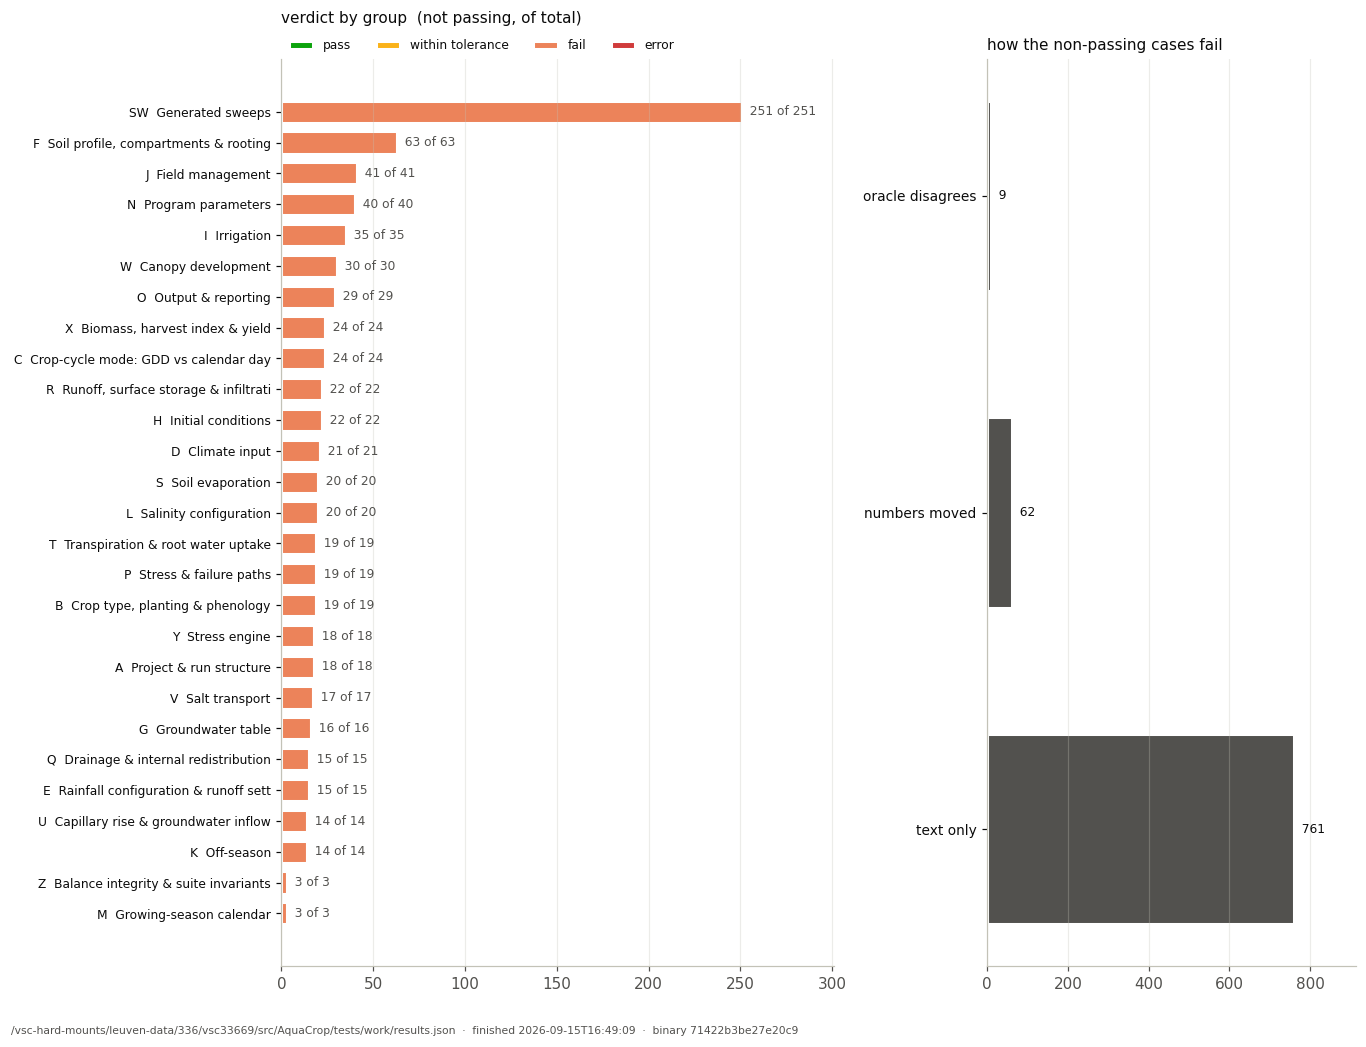

kind,oracle disagrees,numbers moved,text only,total
group,,,,
SW,0,25,226,251
F,9,5,49,63
J,0,0,41,41
N,0,0,40,40
I,0,0,35,35
W,0,0,30,30
O,0,2,27,29
C,0,0,24,24
X,0,0,24,24


In [4]:
VERDICT_ORDER = ["pass", "within tolerance", "fail", "error"]
KIND_ORDER = ["run stopped", "invariant broken", "oracle disagrees",
              "numbers moved", "text only", "unclear"]


def overview(results, all_groups=False):
    """Verdicts per group, and how the non-passing cases fail. Returns the table."""
    table = (pd.crosstab(results["group"], results["verdict"])
               .reindex(columns=VERDICT_ORDER, fill_value=0))
    table["total"] = table.sum(axis=1)
    table["not passing"] = table["fail"] + table["error"]
    shown = table if all_groups else table[table["not passing"] > 0]
    kinds = (results.loc[results["kind"].isin(KIND_ORDER), "kind"]
                    .value_counts().reindex(KIND_ORDER).dropna().astype(int))

    if shown.empty:
        n = int(table["total"].sum())
        print(f"Nothing to show: all {int(table['pass'].sum())} of {n} cases pass "
              f"({int(table['within tolerance'].sum())} within tolerance). "
              f"Use overview(results, all_groups=True) to draw every group anyway.")
        return table.sort_values("total", ascending=False)

    shown = shown.sort_values(["not passing", "total"])
    h = max(2.8, 0.3 * len(shown) + 1.4)
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(12.5, h),
                                 gridspec_kw={"width_ratios": [3, 2]})
    left = np.zeros(len(shown))
    labels = [f"{g}  {GROUP_NAMES.get(g, '')[:36]}" for g in shown.index]
    for v in VERDICT_ORDER:
        vals = shown[v].to_numpy()
        ax.barh(labels, vals, left=left, color=STATUS[v], edgecolor="white",
                linewidth=2, height=0.72, label=v)
        left += vals
    for y, (tot, bad) in enumerate(zip(shown["total"], shown["not passing"])):
        ax.text(tot, y, f"  {bad} of {tot}", va="center", fontsize=8, color=MUTED)
    ax.set_xlim(0, shown["total"].max() * 1.2)
    ax.set_title("verdict by group  (not passing, of total)", fontsize=10, loc="left",
                 pad=24)
    ax.legend(frameon=False, fontsize=8, ncol=4, loc="lower left",
              bbox_to_anchor=(0, 1.0), borderaxespad=0.2)
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=8, colors=INK)

    if len(kinds):
        bx.barh(kinds.index[::-1], kinds.values[::-1], color=MUTED, edgecolor="white",
                linewidth=2, height=0.6)
        for y, v in enumerate(kinds.values[::-1]):
            bx.text(v, y, f"  {v}", va="center", fontsize=8, color=INK)
        bx.set_xlim(0, kinds.max() * 1.2)
    bx.set_title("how the non-passing cases fail", fontsize=10, loc="left")
    bx.grid(axis="y", visible=False)
    bx.tick_params(axis="y", labelsize=9, colors=INK)
    fig.text(0.01, 0.005, results.attrs.get("source", ""), fontsize=7, color=MUTED)
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()
    return shown.sort_values("not passing", ascending=False)


def kinds_by_group(results):
    """The failures as a table: rows are groups, columns are kinds."""
    bad = results[results["kind"].isin(KIND_ORDER)]
    if bad.empty:
        return pd.DataFrame()
    return (pd.crosstab(bad["group"], bad["kind"])
              .reindex(columns=[k for k in KIND_ORDER if k in set(bad["kind"])])
              .assign(total=lambda t: t.sum(axis=1))
              .sort_values("total", ascending=False))


group_table = overview(results)
kinds_by_group(results)

In [5]:
# which output files changed, across every case that has a working tree
def _count(col, name):
    s = results.loc[results[col] != "", col].str.split(", ").explode()
    return s.value_counts().rename(name)


pd.concat([_count("moved", "numbers moved"), _count("text_only", "text only")],
          axis=1).fillna(0).astype(int)

,numbers moved,text only
season.OUT,53,0
day.OUT,46,0
3evaluation.OUT,1,0
harvests.OUT,1,0
ListProjectsLoaded.OUT,0,832


## 2 · Pick cases

`select` filters the table above. Everything after it works on a plain list of case names,
so any selection will do — a group, a kind, a name pattern, or a list typed out by hand.

In [6]:
def select(groups=None, kinds=None, verdicts=("fail", "error"), pattern=None,
           with_tree=True):
    """Case names matching every filter given. None means 'any'."""
    as_list = lambda x: [x] if isinstance(x, str) else list(x)
    r = results
    if groups is not None:
        r = r[r["group"].isin(as_list(groups))]
    if kinds is not None:
        r = r[r["kind"].isin(as_list(kinds))]
    if verdicts is not None:
        r = r[r["verdict"].isin(as_list(verdicts))]
    if pattern is not None:
        r = r[r["case"].str.contains(pattern, case=False, regex=True)]
    if with_tree:
        r = r[r["tree"]]
    return r["case"].tolist()


moved = select(kinds="numbers moved")
print(len(moved), "cases where numbers moved")
results.loc[results["case"].isin(moved), ["case", "group", "kind", "moved"]]

62 cases where numbers moved


,case,group,kind,moved
0,A01_ottawa_prm_baseline,A,numbers moved,"3evaluation.OUT, day.OUT, harvests.OUT, season.OUT"
10,A17_a_run_crossing_a_calendar_year_boundary,A,numbers moved,day.OUT
14,A21_perennial_over_two_runs_carrying_the_profile,A,numbers moved,day.OUT
15,A22_a_second_run_using_a_different_crop_file,A,numbers moved,day.OUT
114,F22_step_4_regrade_overshoots__the_shrink_branch,F,numbers moved,day.OUT
...,...,...,...,...
731,U08_capillary_rise_reaching_the_surface_compartm,U,numbers moved,"day.OUT, season.OUT"
733,U12_capillary_rise_with_a_doubled_gradient_shape,U,numbers moved,"day.OUT, season.OUT"
735,U14_horizontal_inflow_into_compartments_below_th,U,numbers moved,"day.OUT, season.OUT"
738,U19_a_water_table_inside_the_profile__graded_fc,U,numbers moved,"day.OUT, season.OUT"


## 3 · Scatter — reference against new

Every value from the selected cases, pooled over cases and runs, one panel per variable.
Grey points are unchanged and sit on the 1:1 line; orange points moved; the blue dot is the
single largest move, labelled with its case and run.

- `source="day"` pairs daily values by date; `source="season"` pairs season totals by run.
  Many cases write season output only, so a case can be missing from one and present in
  the other.
- `columns=None` draws the variables that moved most; `moved_columns` shows the ranking.
- It returns a summary: per variable, how many values moved and where the worst one is.

In [7]:
def _outputs(case, source):
    ref_dir, new_dir = CASES / case / "OUTP_REF", WORK / case / "OUTP"
    for ref in sorted(ref_dir.glob(f"*{source}.OUT")):
        new = new_dir / ref.name
        if new.is_file():
            yield ref, new


def _merged(case, source):
    """[(file, run, wide frame, columns)]; the frame has 'col|old' and 'col|new'."""
    out = []
    for ref, new in _outputs(case, source):
        if source == "day":
            a_runs, b_runs = parse_day_file(ref), parse_day_file(new)
            for run in sorted(set(a_runs) & set(b_runs)):
                a, b = a_runs[run], b_runs[run]
                cols = [c for c in a.columns if c in b.columns
                        and c not in ("Day", "Month", "Year", "date")]
                m = (a[["date"] + cols].merge(b[["date"] + cols], on="date",
                                              suffixes=("|old", "|new"))
                                       .rename(columns={"date": "key"}))
                out.append((ref.name, run, m, cols))
        else:
            a, b = parse_season_file(ref), parse_season_file(new)
            if a.empty or b.empty:
                continue
            cols = [c for c in a.columns if c in b.columns and c != "run"]
            m = a.merge(b, on="run", suffixes=("|old", "|new"))
            m["key"] = m["run"]
            for run, g in m.groupby("run"):
                out.append((ref.name, int(run), g, cols))
    return out


_CACHE = {}


def merged(case, source):
    """Cached: each output file is parsed once per notebook session."""
    if (case, source) not in _CACHE:
        _CACHE[(case, source)] = _merged(case, source)
    return _CACHE[(case, source)]


_SKIP = {"DAP", "Stage", "RunNr", "Day1", "Month1", "Year1", "DayN", "MonthN", "YearN"}


def collect(cases, source="day", columns=None):
    """Long frame (case, file, run, key, column, old, new) — only the columns asked for."""
    frames = []
    for c in cases:
        for f, run, m, cols in merged(c, source):
            for col in (cols if columns is None else [x for x in columns if x in cols]):
                frames.append(pd.DataFrame({
                    "case": c, "file": f, "run": run, "key": m["key"].to_numpy(),
                    "column": col, "old": _mask(m[f"{col}|old"]).to_numpy(),
                    "new": _mask(m[f"{col}|new"]).to_numpy()}))
    if not frames:
        return pd.DataFrame(columns=["case", "file", "run", "key", "column", "old", "new"])
    return pd.concat(frames, ignore_index=True).dropna(subset=["old", "new"])


def moved_columns(cases, source="day", tol=0.0):
    """Variables ranked by how many values moved. Works on arrays; builds no long frame."""
    stats = {}
    for c in cases:
        for f, run, m, cols in merged(c, source):
            for col in cols:
                if col in _SKIP:
                    continue
                o = m[f"{col}|old"].to_numpy(dtype=float)
                n = m[f"{col}|new"].to_numpy(dtype=float)
                ok = (o > -9.0) & (n > -9.0)
                d = np.abs(n[ok] - o[ok])
                s = stats.setdefault(col, [0, 0, set(), 0.0])
                s[0] += d.size
                k = int((d > tol).sum())
                if k:
                    s[1] += k
                    s[2].add(c)
                    s[3] = max(s[3], float(d.max()))
    if not stats:
        return pd.DataFrame()
    out = pd.DataFrame([{"variable": k, "values": v[0], "moved": v[1], "cases": len(v[2]),
                         "max_abs_dev": v[3]} for k, v in stats.items()]).set_index("variable")
    out["pct_moved"] = (100 * out["moved"] / out["values"].clip(lower=1)).round(2)
    return out.sort_values(["moved", "max_abs_dev"], ascending=False)


def scatter(cases, columns=None, source="day", tol=0.0, ncols=4, size=3.0, top=12):
    """Reference against new, one panel per variable. Returns the per-variable summary."""
    cases = list(cases)
    if columns is None:
        ranking = moved_columns(cases, source, tol)
        if ranking.empty:
            print(f"none of these {len(cases)} case(s) has {source} output in both folders")
            return pd.DataFrame()
        columns = (ranking[ranking["moved"] > 0].head(top).index.tolist()
                   or ranking.head(top).index.tolist())
    columns = list(columns)
    df = collect(cases, source, columns)
    if df.empty:
        print(f"none of these {len(cases)} case(s) has {source} output in both folders")
        return pd.DataFrame()

    nrows = -(-len(columns) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows),
                             squeeze=False)
    axes = axes.ravel()
    rows = []
    for ax, col in zip(axes, columns):
        p = df[df["column"] == col]
        if p.empty:
            ax.set_title(f"{col} — no data", fontsize=9, color=MUTED, loc="left")
            ax.axis("off")
            continue
        d = p["new"] - p["old"]
        mv = d.abs() > tol
        lo = float(min(p["old"].min(), p["new"].min()))
        hi = float(max(p["old"].max(), p["new"].max()))
        pad = (hi - lo) * 0.05 or 0.5
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=SAME, lw=1, zorder=1)
        ax.scatter(p.loc[~mv, "old"], p.loc[~mv, "new"], s=8, color=SAME, lw=0,
                   alpha=0.6, zorder=2, label=f"unchanged ({(~mv).sum():,})")
        rec = {"variable": col, "values": len(p), "moved": int(mv.sum()),
               "pct_moved": round(100 * mv.mean(), 2),
               "cases_moved": p.loc[mv, "case"].nunique(), "max_abs_dev": 0.0,
               "worst_case": None, "worst_run": None, "worst_at": None,
               "worst_ref": None, "worst_new": None}
        if mv.any():
            ax.scatter(p.loc[mv, "old"], p.loc[mv, "new"], s=12, color=MOVED, lw=0,
                       alpha=0.85, zorder=3, label=f"moved ({mv.sum():,})")
            w = p.loc[d.abs().idxmax()]
            ax.scatter([w["old"]], [w["new"]], s=80, facecolor=NEW, edgecolor="white",
                       linewidth=1.6, zorder=5, label="largest move")
            right = w["old"] > (lo + hi) / 2           # keep the label inside the panel
            ax.annotate(f"{w['case'].split('_')[0]} · run {int(w['run'])}",
                        xy=(w["old"], w["new"]), xytext=(-7 if right else 7, -12),
                        ha="right" if right else "left",
                        textcoords="offset points", fontsize=7.5, color=INK, zorder=6)
            at = w["key"].date() if hasattr(w["key"], "date") else int(w["key"])
            rec.update(max_abs_dev=float(d.abs().max()), worst_case=w["case"],
                       worst_run=int(w["run"]), worst_at=at,
                       worst_ref=float(w["old"]), worst_new=float(w["new"]))
            note = (f"{mv.sum():,} of {len(p):,} moved ({mv.mean():.1%})\n"
                    f"{p.loc[mv, 'case'].nunique()} case(s) · max |Δ| {d.abs().max():.4g}")
        else:
            note = f"identical ({len(p):,} values)"
        rows.append(rec)
        ax.set_title(col, fontsize=10, loc="left")
        ax.text(0.03, 0.97, note, transform=ax.transAxes, va="top", fontsize=7.5,
                color=MUTED, linespacing=1.35)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(labelsize=7.5)
    for ax in axes[len(columns):]:
        ax.axis("off")
    # one legend for the whole grid: per-panel legends sit on top of dense data
    from matplotlib.lines import Line2D
    handles = [Line2D([], [], ls="", marker="o", ms=5, color=SAME, label="unchanged"),
               Line2D([], [], ls="", marker="o", ms=5, color=MOVED, label="moved"),
               Line2D([], [], ls="", marker="o", ms=8, markerfacecolor=NEW,
                      markeredgecolor="white", label="largest move (case · run)")]
    fig.legend(handles=handles, loc="upper right", ncol=3, frameon=False, fontsize=8.5,
               bbox_to_anchor=(1, 1.0))
    fig.supxlabel("reference  (tests/cases/…/OUTP_REF)", fontsize=9, color=MUTED)
    fig.supylabel("new  (work/…/OUTP)", fontsize=9, color=MUTED)
    fig.suptitle(f"reference against new · {len(cases)} case(s) · {source} output",
                 fontsize=11, x=0.01, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
    return pd.DataFrame(rows).sort_values("moved", ascending=False).reset_index(drop=True)

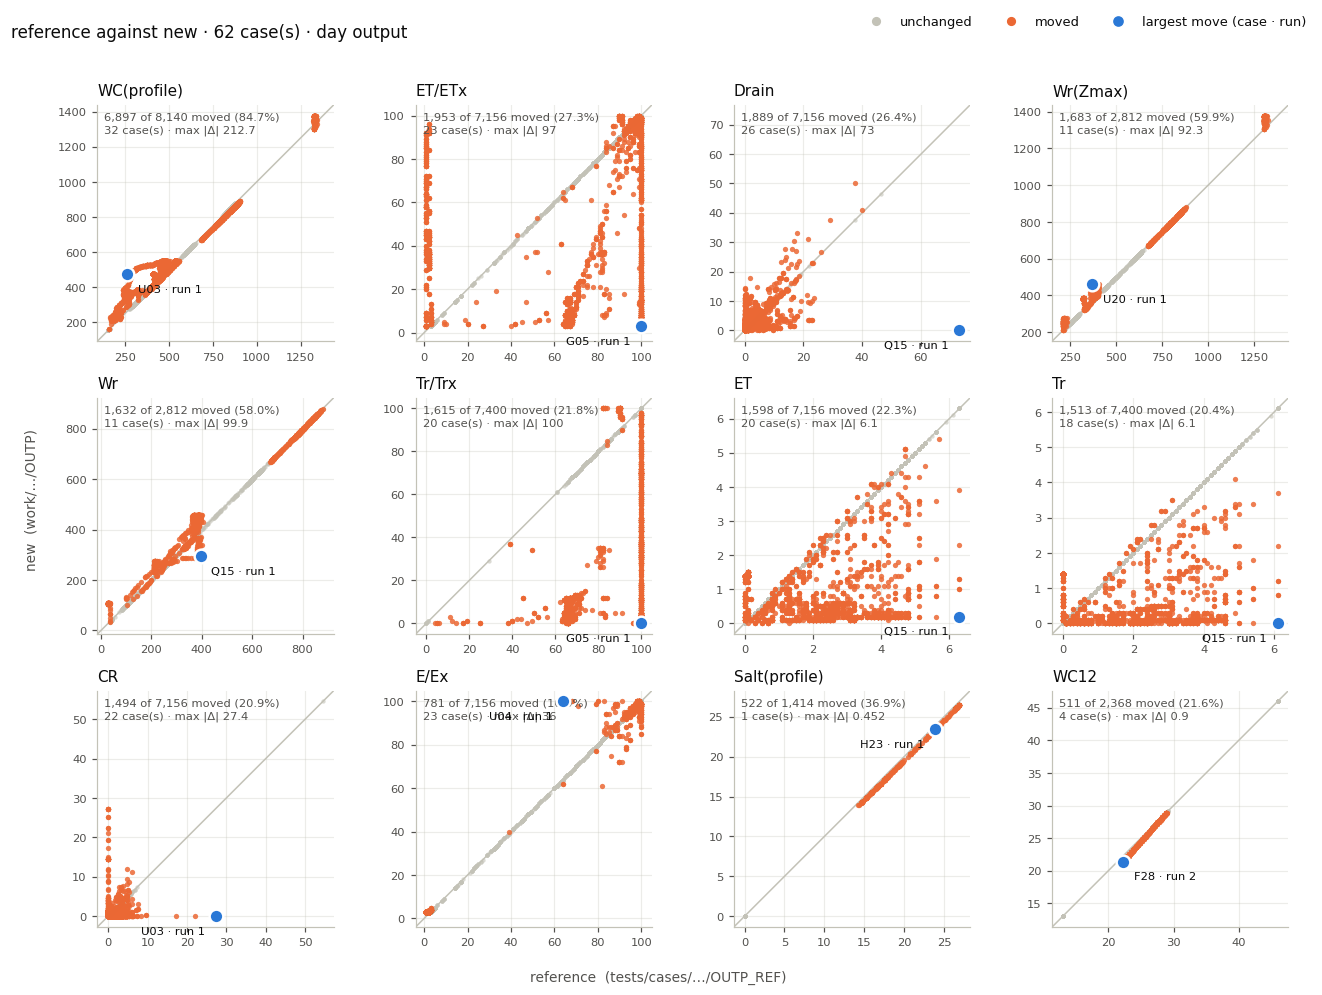

,variable,values,moved,pct_moved,cases_moved,max_abs_dev,worst_case,worst_run,worst_at,worst_ref,worst_new
0,WC(profile),8140,6897,84.73,32,212.700,U03_capillary_rise_from_1_0_m,1,2014-08-30,263.200,475.900
1,ET/ETx,7156,1953,27.29,23,97.000,G05_constant_table_at_1_0_m__inside_the_profile,1,2014-08-13,100.000,3.000
2,Drain,7156,1889,26.40,26,73.000,Q15_drainage_against_an_adjusted_field_capacity,1,2014-05-21,73.100,0.100
3,Wr(Zmax),2812,1683,59.85,11,92.300,U20_a_water_table_moving_through_the_season,1,2014-08-14,367.600,459.900
4,Wr,2812,1632,58.04,11,99.900,Q15_drainage_against_an_adjusted_field_capacity,1,2014-07-08,395.000,295.100
5,Tr/Trx,7400,1615,21.82,20,100.000,G05_constant_table_at_1_0_m__inside_the_profile,1,2014-08-13,100.000,0.000
6,ET,7156,1598,22.33,20,6.100,Q15_drainage_against_an_adjusted_field_capacity,1,2014-06-27,6.300,0.200
7,Tr,7400,1513,20.45,18,6.100,Q15_drainage_against_an_adjusted_field_capacity,1,2014-06-27,6.100,0.000
8,CR,7156,1494,20.88,22,27.400,U03_capillary_rise_from_1_0_m,1,2014-12-11,27.400,0.000
9,E/Ex,7156,781,10.91,23,36.000,U04_capillary_rise_from_0_4_m_into_the_evaporati,1,2014-08-11,64.000,100.000


In [8]:
# daily values of every case whose numbers moved
summary_day = scatter(moved, source="day")
summary_day

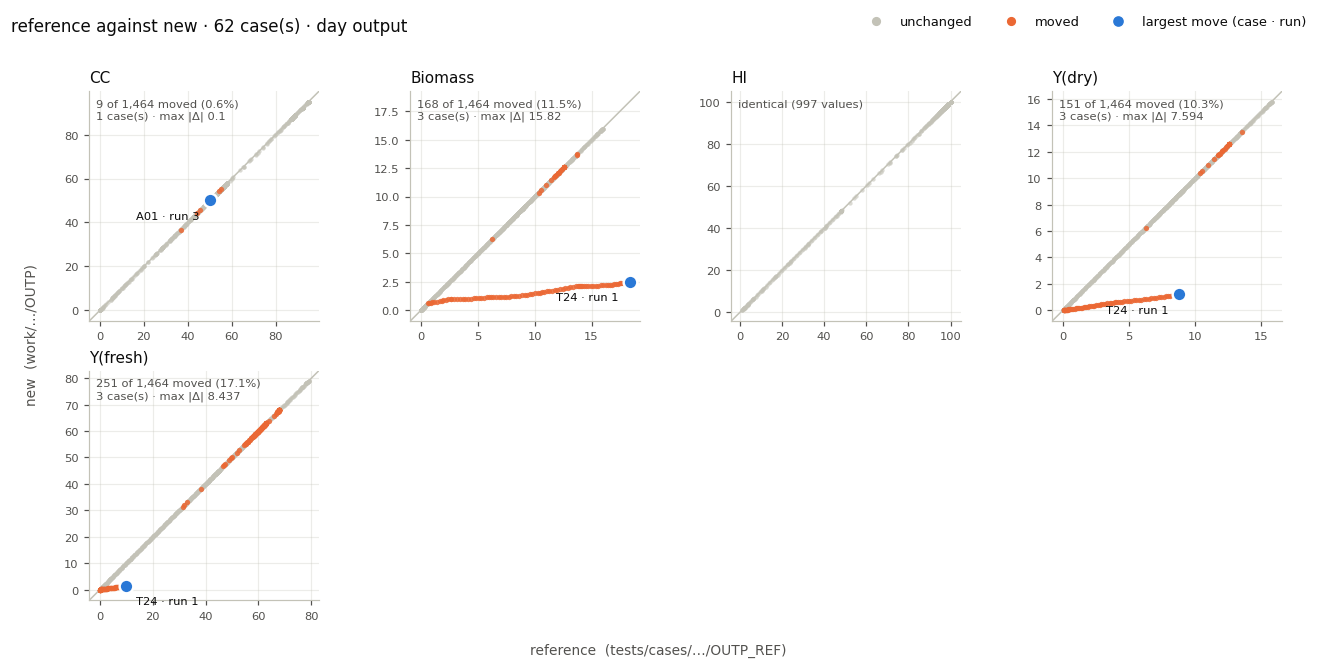

,variable,values,moved,pct_moved,cases_moved,max_abs_dev,worst_case,worst_run,worst_at,worst_ref,worst_new
0,Y(fresh),1464,251,17.14,3,8.437,T24_uptake_from_a_root_zone_reaching_the_water_t,1.0,2014-09-24,9.781,1.344
1,Biomass,1464,168,11.48,3,15.820,T24_uptake_from_a_root_zone_reaching_the_water_t,1.0,2014-09-25,18.340,2.520
2,Y(dry),1464,151,10.31,3,7.594,T24_uptake_from_a_root_zone_reaching_the_water_t,1.0,2014-09-24,8.803,1.209
3,CC,1464,9,0.61,1,0.100,A01_ottawa_prm_baseline,3.0,2016-07-31,50.200,50.100
4,HI,997,0,0.00,0,0.000,None,NaN,None,NaN,NaN


In [9]:
# crop development only, day by day: canopy, biomass, harvest index, yield
CROP = ["CC", "Biomass", "HI", "Y(dry)", "Y(fresh)"]
if len(moved):
    display(scatter(moved, columns=CROP, source="day"))

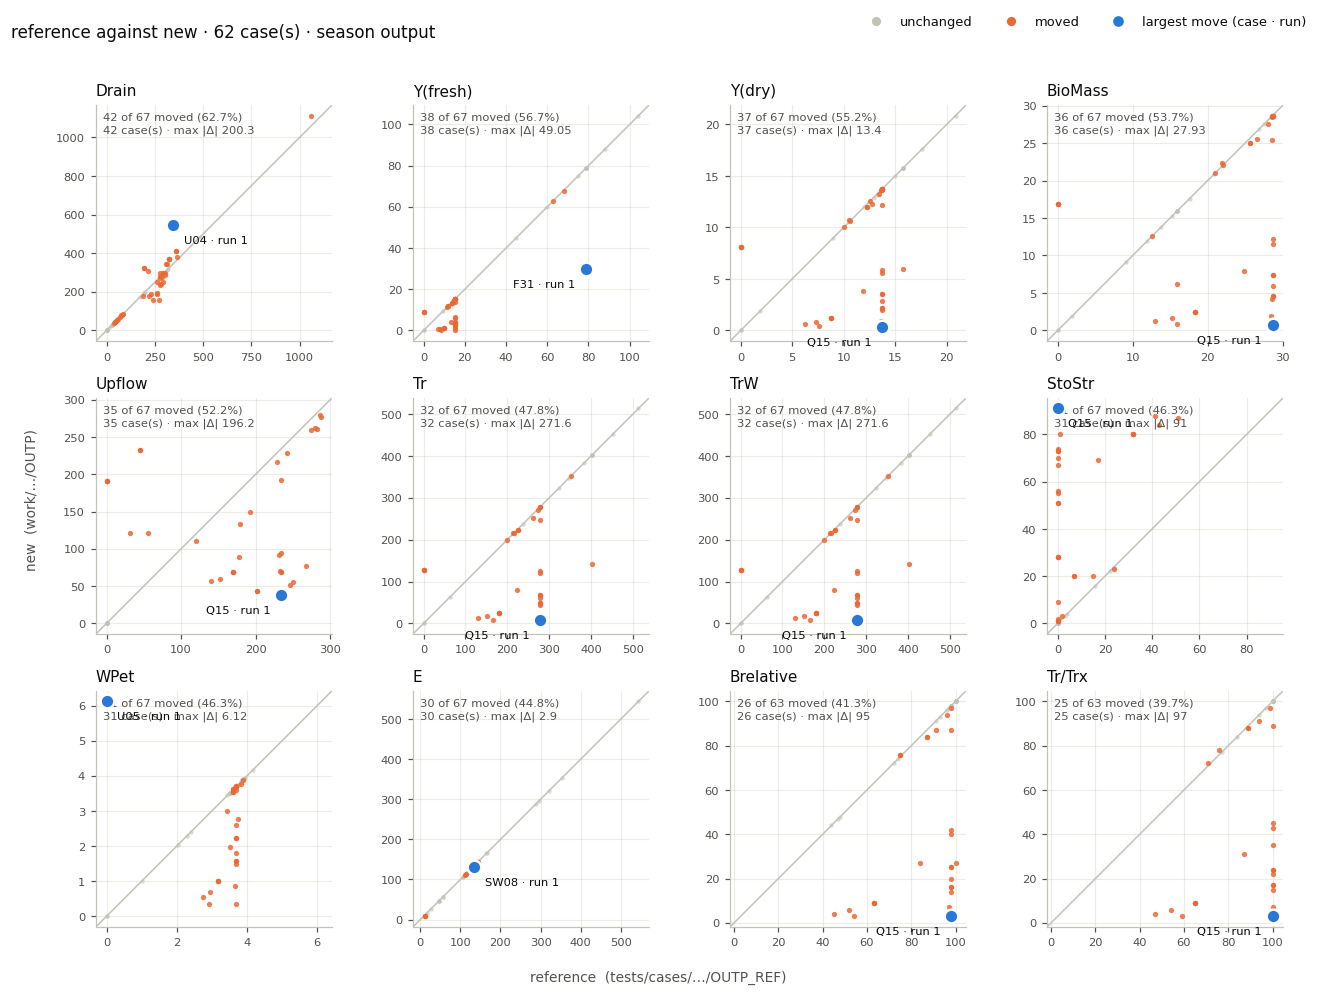

,variable,values,moved,pct_moved,cases_moved,max_abs_dev,worst_case,worst_run,worst_at,worst_ref,worst_new
0,Drain,67,42,62.69,42,200.300,U04_capillary_rise_from_0_4_m_into_the_evaporati,1,1,346.500,546.800
1,Y(fresh),67,38,56.72,38,49.053,F31_compartment_expansion_with_a_water_table_pre,1,1,78.965,29.912
2,Y(dry),67,37,55.22,37,13.404,Q15_drainage_against_an_adjusted_field_capacity,1,1,13.757,0.353
3,BioMass,67,36,53.73,36,27.926,Q15_drainage_against_an_adjusted_field_capacity,1,1,28.661,0.735
4,Upflow,67,35,52.24,35,196.200,Q15_drainage_against_an_adjusted_field_capacity,1,1,234.200,38.000
5,Tr,67,32,47.76,32,271.600,Q15_drainage_against_an_adjusted_field_capacity,1,1,279.200,7.600
6,TrW,67,32,47.76,32,271.600,Q15_drainage_against_an_adjusted_field_capacity,1,1,279.200,7.600
7,StoStr,67,31,46.27,31,91.000,Q15_drainage_against_an_adjusted_field_capacity,1,1,0.000,91.000
8,WPet,67,31,46.27,31,6.120,U05_capillary_rise_hitting_its_daily_upper_limit,1,1,0.000,6.120
9,E,67,30,44.78,30,2.900,SW08_const_1p0_loam,1,1,134.400,131.500


In [10]:
# season totals of the same cases — season-only cases appear here and not above
summary_season = scatter(moved, source="season")
summary_season

## 4 · Zoom into one case

`divergence(case)` lists every variable that moved: the first date it differs, on how many
days, and the largest difference. `plot_case` draws the reference (orange, dashed) and the
new build (blue, solid), the difference beneath, and a dotted line on the first day of
divergence. That first day usually says more than the largest difference, because everything
after it can be a consequence.

- `columns="crop"` draws canopy cover, biomass, harvest index and yield day by day (needs daily
  output block 2); `columns="water"` draws the soil water and its fluxes. Any list of column
  names works too.
- **`Wr` is drawn with its reference points**: `Wr(SAT)` (dotted), `Wr(FC)` (dashed) and
  `Wr(PWP)` (dash-dot), the root-zone water at saturation, field capacity and wilting point, as
  AquaCrop writes them. They move with the root depth, so they are curves, not flat lines. The
  band between wilting point and field capacity is shaded. If the reference build's lines differ
  from the new build's (a different root depth), they are drawn too, in the reference colour.
  `thresholds=True` adds the stress thresholds `Wr(exp)`, `Wr(sto)` and `Wr(sen)`.

`season_table(case)` puts the season totals side by side, for reading exact values.

In [11]:
def divergence(case, source="day", tol=0.0):
    """Per file, run and variable: where it first differs and by how much at most."""
    out = []
    for f, run, m, cols in merged(case, source):
        for col in cols:
            if col in _SKIP:
                continue
            o, n = _mask(m[f"{col}|old"]), _mask(m[f"{col}|new"])
            d = (n - o)
            mv = d.abs() > tol
            if not mv.any():
                continue
            j = d.abs().idxmax()
            # relative to the range the variable covers in either run: dividing by the largest
            # value instead scores every variable that starts from zero at exactly 1.0
            rng = float(np.nanmax([o.max(), n.max()]) - np.nanmin([o.min(), n.min()]))
            if rng <= 1e-12:
                rng = max(float(np.nanmax(np.abs(o))), float(np.nanmax(np.abs(n))), 1e-12)
            out.append({"file": f, "run": run, "variable": col,
                        "first_divergence": m.loc[mv[mv].index[0], "key"],
                        "days_moved": int(mv.sum()), "of": int(d.notna().sum()),
                        "max_abs_dev": float(abs(d[j])), "rel_to_range": abs(d[j]) / rng,
                        "at": m.loc[j, "key"], "ref": float(o[j]), "new": float(n[j])})
    if not out:
        return pd.DataFrame()
    return (pd.DataFrame(out)
              .sort_values(["file", "run", "first_divergence", "rel_to_range"],
                           ascending=[True, True, True, False])
              .reset_index(drop=True))


def season_table(case, only_changed=True):
    rows = []
    for f, run, m, cols in merged(case, "season"):
        for c in cols:
            a, b = float(m[f"{c}|old"].iloc[0]), float(m[f"{c}|new"].iloc[0])
            if only_changed and a == b:
                continue
            rows.append({"file": f, "run": run, "variable": c, "reference": a,
                         "new": b, "Δ": b - a})
    return pd.DataFrame(rows)


PRESETS = {
    "crop":  ["CC", "Biomass", "HI", "Y(dry)", "Y(fresh)", "Tr"],
    "water": ["Wr", "WC(profile)", "Tr", "E", "Drain", "CR"],
}
_WR_REFS = {"Wr(SAT)": ("SAT", ":"), "Wr(FC)": ("FC", "--"), "Wr(PWP)": ("PWP", "-.")}
_WR_THRESHOLDS = {"Wr(exp)": "exp", "Wr(sto)": "sto", "Wr(sen)": "sen"}
_BAND_COLUMNS = set(_WR_REFS) | set(_WR_THRESHOLDS)


def _wr_references(ax, a, b, thresholds=False):
    """Draw Wr(SAT), Wr(FC), Wr(PWP) along Wr, labelled at their right-hand end."""
    if not all(c in b.columns for c in _WR_REFS):
        return
    x = b["date"]
    labels = []                                   # (y at the right edge, text)
    ax.fill_between(x, b["Wr(PWP)"], b["Wr(FC)"], color=SAME, alpha=0.22, lw=0, zorder=0)
    for col, (label, ls) in _WR_REFS.items():
        ax.plot(x, b[col], color=MUTED, ls=ls, lw=1.1, zorder=1)
        labels.append((float(b[col].iloc[-1]), label))
        if col in a.columns:
            m = (pd.DataFrame({"date": a["date"], "o": a[col]})
                   .merge(pd.DataFrame({"date": x, "n": b[col]}), on="date"))
            if (m["o"] - m["n"]).abs().max() > 0.05:
                ax.plot(a["date"], a[col], color=MOVED, ls=ls, lw=0.9, alpha=0.55, zorder=1)
    if thresholds:
        for col, label in _WR_THRESHOLDS.items():
            if col in b.columns:
                ax.plot(x, b[col], color=SAME, lw=0.9, zorder=1)
                labels.append((float(b[col].iloc[-1]), label))
    # labels that would print on top of each other are joined: "sto/sen"
    labels.sort()
    span = max(y for y, _ in labels) - min(y for y, _ in labels) or 1.0
    merged = []
    for y, t in labels:
        if merged and y - merged[-1][0] < 0.04 * span:
            merged[-1] = (merged[-1][0], merged[-1][1] + "/" + t)
        else:
            merged.append((y, t))
    for y, t in merged:
        ax.annotate(f" {t}", xy=(x.iloc[-1], y), fontsize=7, color=MUTED, va="center",
                    annotation_clip=False)


def plot_case(case, columns=None, run=None, file=None, max_columns=8, tol=0.0,
              thresholds=False):
    """Reference and new over time, with the difference underneath each variable.

    columns: None (the variables that moved most), "crop", "water", or a list of names.
    """
    div = divergence(case, "day", tol)
    files = [n.name for _, n in _outputs(case, "day")]
    if not files:
        print(f"{case} writes no daily output — here are its season totals")
        return season_table(case)
    file = file or (div["file"].iloc[0] if not div.empty else files[0])
    if div.empty:
        div = pd.DataFrame(columns=["file", "run", "variable", "rel_to_range"])
    ref_runs = parse_day_file(CASES / case / "OUTP_REF" / file)
    new_runs = parse_day_file(WORK / case / "OUTP" / file)
    if run is None:
        here = div[div["file"] == file]
        run = int(here["run"].iloc[0]) if not here.empty else min(ref_runs)
    a, b = ref_runs[run], new_runs[run]
    if isinstance(columns, str):
        preset = columns
        columns = [c for c in PRESETS[preset] if c in a.columns and c in b.columns]
        if not columns:
            need = "daily block 2 (crop)" if preset == "crop" else "daily blocks 1 or 3 (water)"
            print(f"{case} has none of the '{preset}' columns in {file} — it needs {need}")
            return div
    elif columns is None:
        pick = div[(div["file"] == file) & (div["run"] == run)
                   & ~div["variable"].isin(_BAND_COLUMNS)]
        columns = (pick.sort_values("rel_to_range", ascending=False)["variable"]
                       .head(max_columns).tolist())
        if not columns:
            print(f"{case}: nothing moved in {file}, run {run}")
            return div

    height = 2.3 * len(columns) + 0.9
    fig = plt.figure(figsize=(11, height))
    # fixed margins in inches, so tall figures do not open a gap above the first panel
    gs = GridSpec(2 * len(columns), 1, figure=fig, height_ratios=[3, 1] * len(columns),
                  hspace=0.15, top=1 - 0.75 / height, bottom=0.45 / height,
                  left=0.08, right=0.93)
    top = None
    for i, col in enumerate(columns):
        ax = fig.add_subplot(gs[2 * i], sharex=top)
        top = top or ax
        dx = fig.add_subplot(gs[2 * i + 1], sharex=top)
        if col not in a.columns or col not in b.columns:
            ax.set_title(f"{col} — not in both files", fontsize=9, color=MUTED, loc="left")
            continue
        ya, yb = _mask(a[col]), _mask(b[col])
        if col == "Wr":
            _wr_references(ax, a, b, thresholds)
        ax.plot(a["date"], ya, color=MOVED, ls="--", lw=2, label="reference")
        ax.plot(b["date"], yb, color=NEW, ls="-", lw=2, alpha=0.9, label="new")
        m = (pd.DataFrame({"date": a["date"], "o": ya})
               .merge(pd.DataFrame({"date": b["date"], "n": yb}), on="date"))
        delta = m["n"] - m["o"]
        dx.axhline(0, color=SAME, lw=1)
        dx.fill_between(m["date"], delta, 0, color=MUTED, alpha=0.2, lw=0)
        dx.plot(m["date"], delta, color=MUTED, lw=1.2)
        changed = m[delta.abs() > tol]
        if not changed.empty:
            d0 = changed["date"].iloc[0]
            for axx in (ax, dx):
                axx.axvline(d0, color=INK, lw=0.8, ls=":")
            ax.annotate(f" first divergence {d0:%d %b %Y}", xy=(d0, 1),
                        xycoords=("data", "axes fraction"), va="top", fontsize=7.5,
                        color=INK)
            j = delta.abs().idxmax()
            dx.text(0.005, 0.92, f"max Δ {delta[j]:+.4g} on {m['date'][j]:%d %b %Y}",
                    transform=dx.transAxes, fontsize=7, color=INK, va="top")
        ax.set_ylabel(col, fontsize=9, color=INK)
        dx.set_ylabel("Δ", fontsize=8)
        ax.tick_params(labelbottom=False, labelsize=7.5)
        dx.tick_params(labelbottom=(i == len(columns) - 1), labelsize=7.5)
        if i == 0:
            ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower right",
                      bbox_to_anchor=(1, 1.0))
    da, db = a.attrs.get("depths", {}).get("WC"), b.attrs.get("depths", {}).get("WC")
    depth = f" · profile {da} m → {db} m" if da and db and da != db else ""
    if b.attrs.get("year_shift"):
        depth += (f" · years shifted by +{b.attrs['year_shift']} to plot them"
                  f" (this run is not linked to a calendar year)")
    fig.suptitle(f"{case} · {file} · run {run}{depth}", fontsize=11, x=0.01, ha="left",
                 y=1 - 0.12 / height)
    plt.show()
    return div

,case,largest_relative_move,variables_moved
0,A01_ottawa_prm_baseline,1.000000,42
1,U19_a_water_table_inside_the_profile__graded_fc,1.000000,28
2,U14_horizontal_inflow_into_compartments_below_th,1.000000,20
3,U20_a_water_table_moving_through_the_season,1.000000,20
4,G14_water_table_observations_ending_before_the_s,1.000000,18
5,Q15_drainage_against_an_adjusted_field_capacity,1.000000,18
6,U08_capillary_rise_reaching_the_surface_compartm,1.000000,15
7,U04_capillary_rise_from_0_4_m_into_the_evaporati,1.000000,14
8,F31_compartment_expansion_with_a_water_table_pre,1.000000,13
9,G12_variable_table_rising_then_falling,1.000000,11


zooming into A01_ottawa_prm_baseline


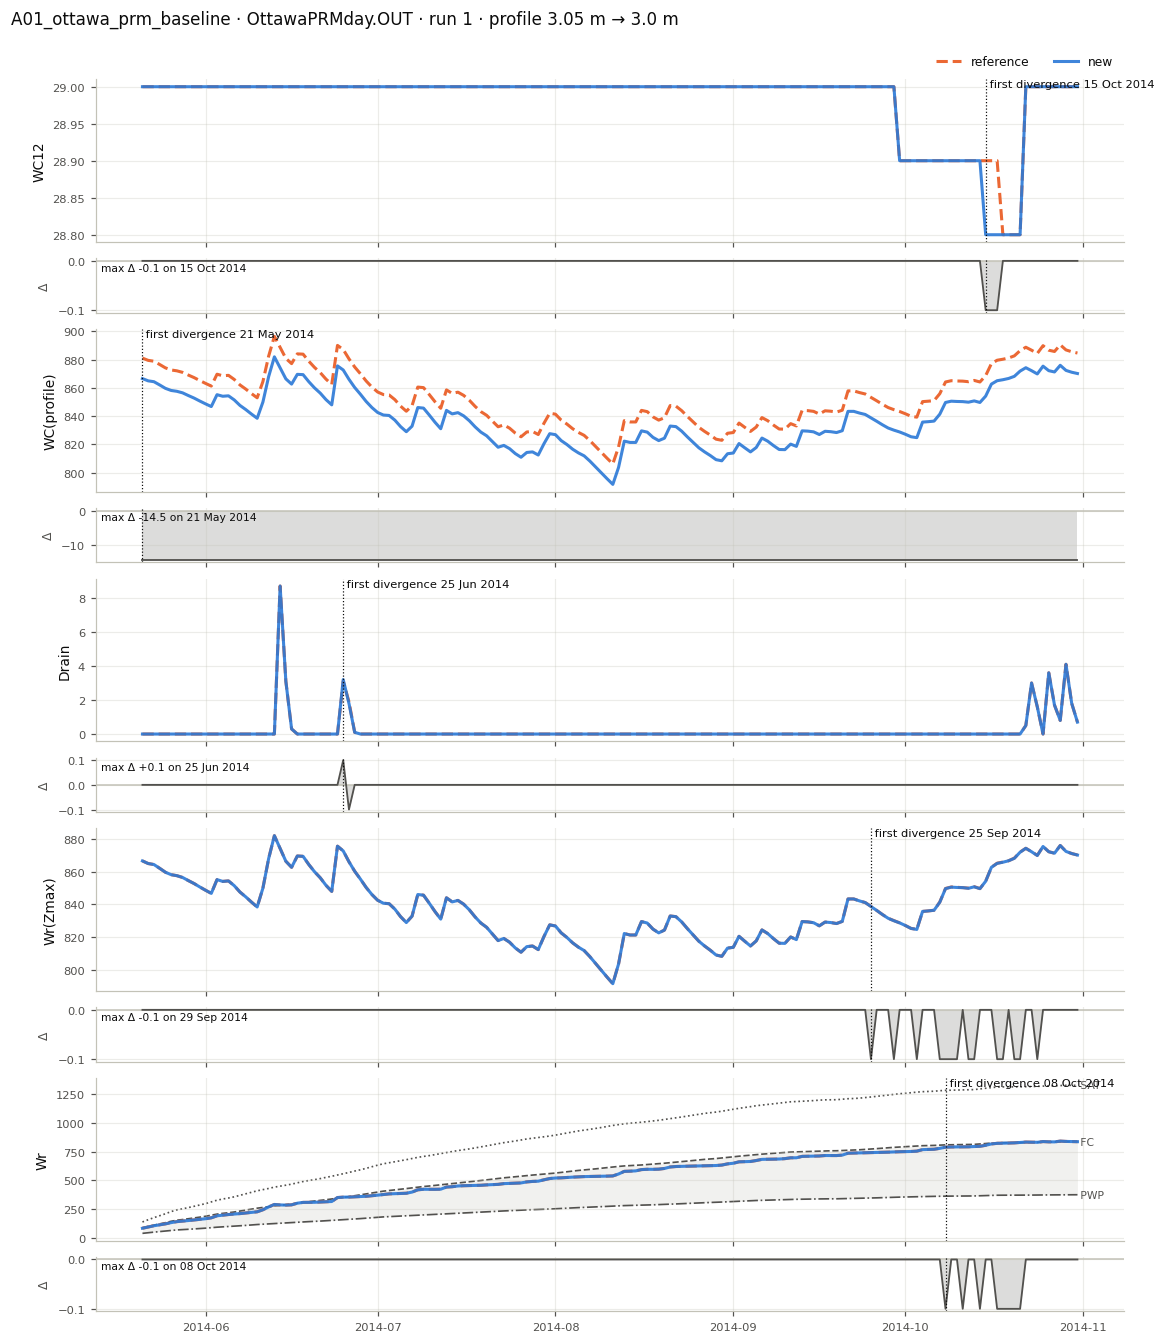

,file,run,variable,first_divergence,days_moved,of,max_abs_dev,rel_to_range,at,ref,new
0,OttawaPRMday.OUT,1,WC(profile),2014-05-21,164,164,14.500,0.138359,2014-05-21,881.000,866.500
1,OttawaPRMday.OUT,1,Drain,2014-06-25,2,164,0.100,0.011494,2014-06-25,3.100,3.200
2,OttawaPRMday.OUT,1,Wr(Zmax),2014-09-25,14,164,0.100,0.001107,2014-09-29,830.100,830.000
3,OttawaPRMday.OUT,1,Wr,2014-10-08,8,164,0.100,0.000132,2014-10-08,789.100,789.000
4,OttawaPRMday.OUT,1,WC12,2014-10-15,3,164,0.100,0.500000,2014-10-15,28.900,28.800
5,OttawaPRMday.OUT,2,WC(profile),2014-11-01,358,358,14.600,0.102241,2014-12-18,887.200,872.600
6,OttawaPRMday.OUT,2,Drain,2014-11-18,7,358,0.100,0.008547,2015-04-11,8.700,8.800
7,OttawaPRMday.OUT,2,WC12,2015-05-02,168,358,0.800,0.112676,2015-09-19,23.100,22.300
8,OttawaPRMday.OUT,2,Wr(Zmax),2015-05-04,174,177,3.200,0.031008,2015-10-07,773.100,769.900
9,OttawaPRMday.OUT,2,Wr,2015-05-04,174,177,3.200,0.031008,2015-10-07,773.100,769.900


In [12]:
# Zoom into the case that moved most. Absolute differences cannot be compared across
# variables (17.9 mm of soil water against 0.4 mm of transpiration), so each case is scored
# by its largest difference RELATIVE to the variable's range in that case.
def most_moved(cases, source="day"):
    scores = []
    for c in cases:
        dv = divergence(c, source)
        if not dv.empty:
            scores.append((c, float(dv["rel_to_range"].max()), len(dv)))
    return (pd.DataFrame(scores, columns=["case", "largest_relative_move", "variables_moved"])
              .sort_values(["largest_relative_move", "variables_moved"], ascending=False)
              .reset_index(drop=True))


if len(moved):
    ranking = most_moved(moved)
    display(ranking)
    case = ranking["case"].iloc[0] if len(ranking) else moved[0] # change iloc for other case
    print("zooming into", case)
    div = plot_case(case)
    display(div.head(15))
else:
    print("no case with moved numbers — nothing to zoom into")

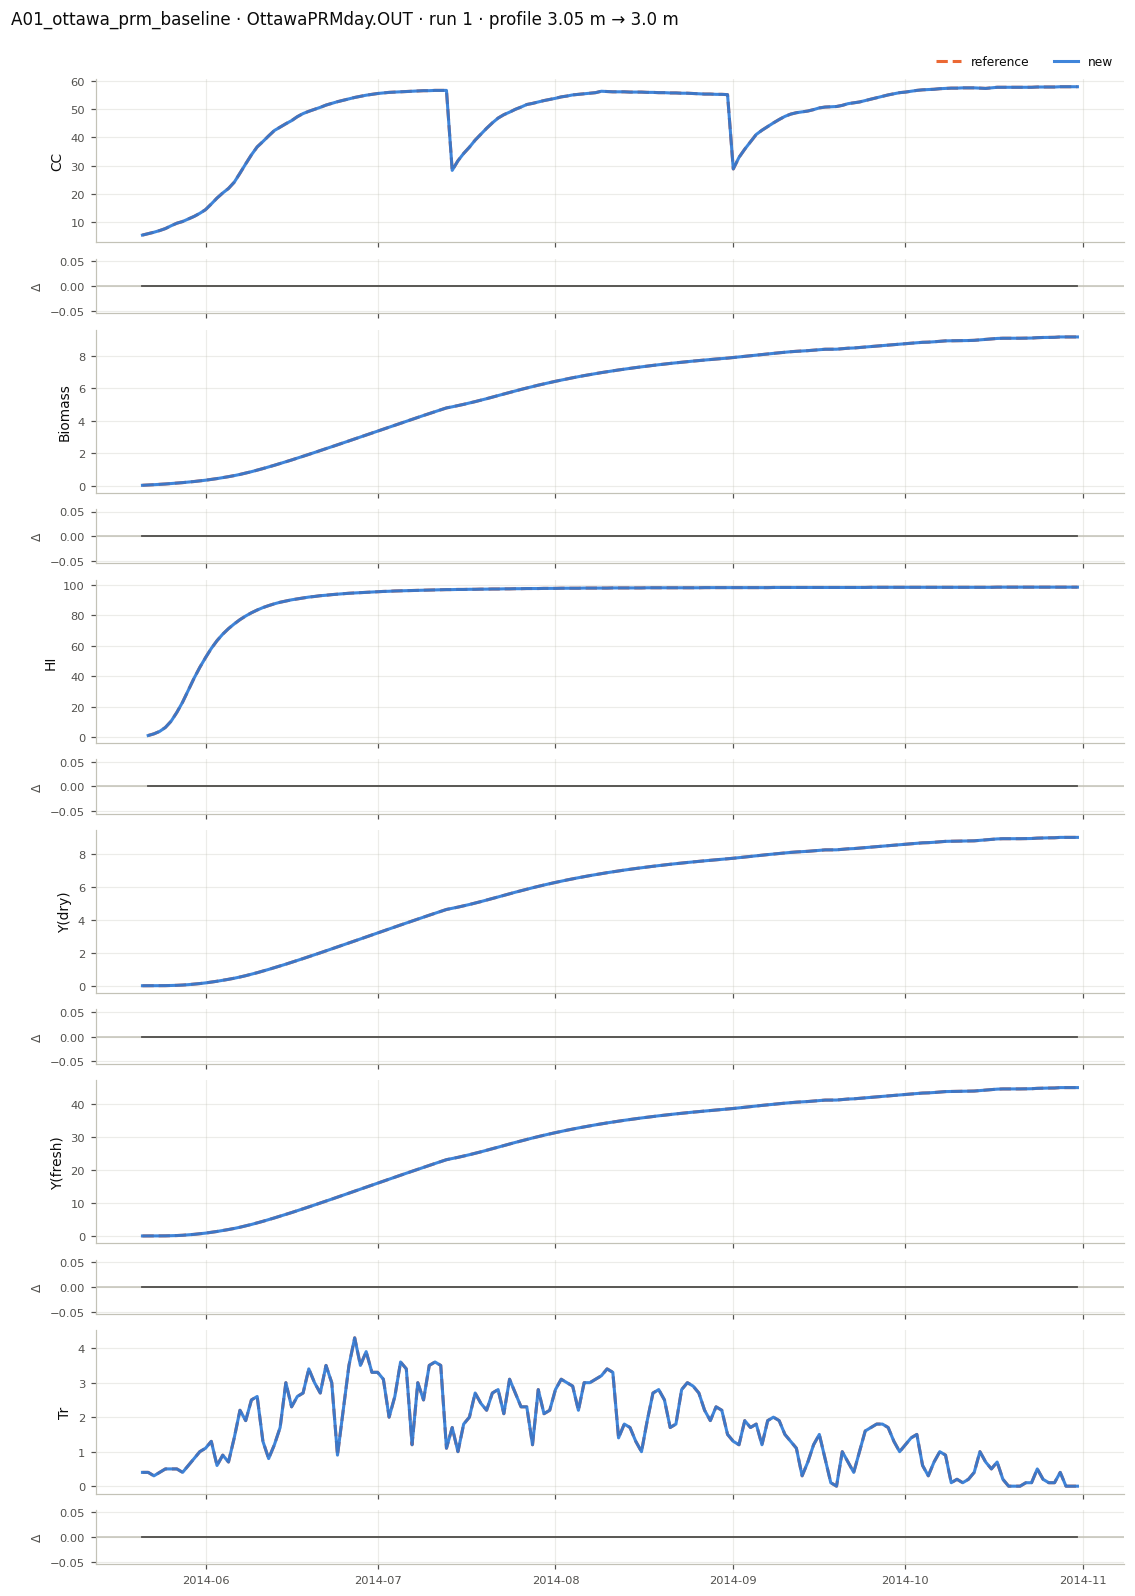

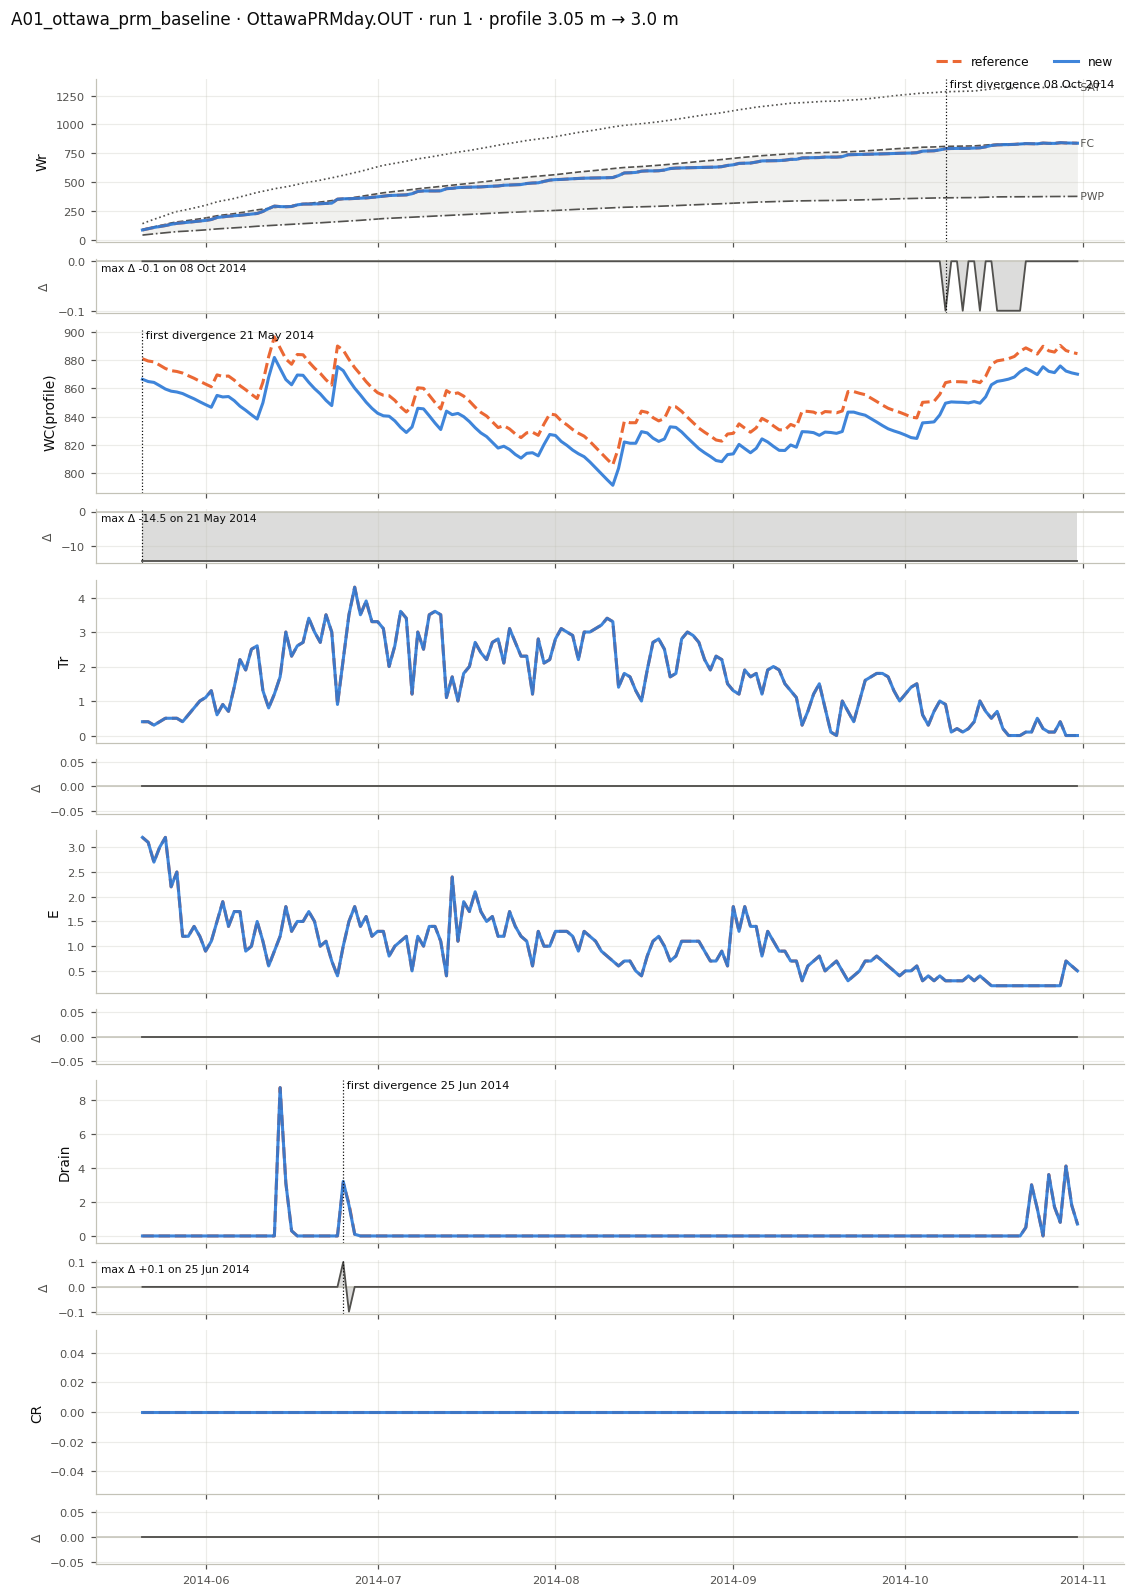

In [13]:
# the same case, crop development day by day, and its soil water with the root-zone
# reference points drawn along Wr
if len(moved):
    plot_case(case, columns="crop")
    plot_case(case, columns="water")

In [14]:
# or name any case directly, for example:
#   plot_case("G05_constant_table_at_1_0_m__inside_the_profile", columns=["Tr", "CR", "Drain"])
if len(moved):
    display(season_table(case))

,file,run,variable,reference,new,Δ
0,OttawaPRMseason.OUT,3,Tr,351.600,351.500,-0.100
1,OttawaPRMseason.OUT,3,TrW,351.600,351.500,-0.100
2,OttawaPRMseason.OUT,3,BioMass,12.581,12.582,0.001
3,OttawaPRMseason.OUT,3,Y(dry),12.581,12.582,0.001
4,OttawaPRMseason.OUT,3,Y(fresh),62.907,62.909,0.002
5,OttawaPRMseason.OUT,3,Bout,2.449,2.448,-0.001


## 5 · Interactive picker

Dropdowns over the same functions: narrow by group and kind, then choose a case. Needs
`ipywidgets`, which the `louise` env has; without it this cell prints a note, and every
function above still works when called by hand.

In [15]:
try:
    import ipywidgets as W
    from IPython.display import display, clear_output
except ImportError:
    W = None
    print("ipywidgets is not available — call select, scatter and plot_case directly")

candidates = results[results["kind"].isin(KIND_ORDER) & results["tree"]]
if W is not None and candidates.empty:
    print("no failing case with a working tree — the picker has nothing to offer")
elif W is not None:
    g_dd = W.Dropdown(options=["(all)"] + sorted(candidates["group"].unique()),
                      description="group")
    k_dd = W.Dropdown(options=["(all)"] + [k for k in KIND_ORDER
                                           if k in set(candidates["kind"])],
                      description="kind")
    c_dd = W.Dropdown(options=[], description="case", layout=W.Layout(width="560px"))
    src = W.ToggleButtons(options=["day", "season"], description="scatter")
    b_sc = W.Button(description="scatter these cases")
    b_zm = W.Button(description="zoom into case", button_style="primary")
    out = W.Output()

    def _refresh(*_):
        r = candidates
        if g_dd.value != "(all)":
            r = r[r["group"] == g_dd.value]
        if k_dd.value != "(all)":
            r = r[r["kind"] == k_dd.value]
        c_dd.options = r["case"].tolist()

    def _scatter(_):
        with out:
            clear_output(wait=True)
            display(scatter(list(c_dd.options), source=src.value))

    def _zoom(_):
        with out:
            clear_output(wait=True)
            if c_dd.value:
                display(plot_case(c_dd.value).head(20))
                display(season_table(c_dd.value))

    g_dd.observe(_refresh, "value")
    k_dd.observe(_refresh, "value")
    b_sc.on_click(_scatter)
    b_zm.on_click(_zoom)
    _refresh()
    display(W.VBox([W.HBox([g_dd, k_dd]), c_dd, W.HBox([src, b_sc, b_zm]), out]))